# FEARS Pipeline Output — Exploratory Data Analysis

This notebook performs EDA on the final pipeline output:
- `data/adult/patient_report_reporter_drug_reaction_full_data.parquet`
- `data/pediatric/patient_report_reporter_drug_reaction_full_data.parquet`

Each row = 1 unique (report × drug × reaction) event after quality filtering + RxNorm enrichment + MedDRA mapping.

**Run on SLURM** (requires polars + matplotlib in the `fulldata` conda env).

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 120, "font.size": 11})

# --- Load data ---
DATA_ROOT = Path("../data/output")

adult = pl.read_parquet(DATA_ROOT / "Adult" / "patient_report_reporter_drug_reaction_full_data.parquet")
pediatric = pl.read_parquet(DATA_ROOT / "Pediatric" / "patient_report_reporter_drug_reaction_full_data.parquet")

print(f"Adult:      {adult.height:>10,} rows  x  {adult.width} columns")
print(f"Pediatric:  {pediatric.height:>10,} rows  x  {pediatric.width} columns")
print(f"Total:      {adult.height + pediatric.height:>10,} rows")

Adult:      17,813,299 rows  x  33 columns
Pediatric:     953,037 rows  x  34 columns
Total:      18,766,336 rows


## 1. Schema Overview

In [3]:
# Schema + null % for both cohorts
def schema_summary(df: pl.DataFrame, name: str) -> pl.DataFrame:
    rows = []
    for col in df.columns:
        dtype = str(df.schema[col])
        null_pct = round(df[col].null_count() / df.height * 100, 1) if df.height > 0 else 0
        n_unique = df[col].n_unique() if not dtype.startswith("List") else None
        rows.append({"column": col, "dtype": dtype, "null_%": null_pct, "n_unique": n_unique})
    return pl.DataFrame(rows).with_columns(pl.lit(name).alias("cohort"))

schema_df = pl.concat([schema_summary(adult, "adult"), schema_summary(pediatric, "pediatric")])

# Pivot: one row per column, adult vs pediatric null %
pivot = (
    schema_df
    .pivot(on="cohort", index=["column", "dtype"], values="null_%")
    .rename({"adult": "null%_adult", "pediatric": "null%_pediatric"})
)
display(pivot)

column,dtype,null%_adult,null%_pediatric
str,str,f64,f64
"""safetyreportid""","""String""",0.0,0.0
"""age_years""","""Int32""",0.0,0.0
"""patient_sex""","""String""",0.0,0.0
"""receive_date""","""Date""",0.0,0.0
"""mostrecent_receive_date""","""Date""",0.0,0.0
…,…,…,…
"""meddra_concept_id""","""Int64""",0.0,0.0
"""meddra_concept_code""","""String""",0.0,0.0
"""meddra_soc_codes""","""List(String)""",0.0,0.0


## 2. Key Metrics Summary

In [4]:
def cohort_metrics(df: pl.DataFrame, name: str) -> dict:
    return {
        "Cohort": name,
        "Total rows": f"{df.height:,}",
        "Unique reports": f'{df["safetyreportid"].n_unique():,}',
        "Unique drugs (medicinal_product)": f'{df["medicinal_product"].n_unique():,}',
        "Unique RxCUI": f'{df.filter(pl.col("rxcui").is_not_null())["rxcui"].n_unique():,}',
        "Unique reactions (PT)": f'{df["reaction_meddrapt"].n_unique():,}',
        "Serious events (%)": f'{df.filter(pl.col("serious") == 1).height / df.height * 100:.1f}%' if "serious" in df.columns and df.height > 0 else "N/A",
        "Date range": f'{df["receive_date"].min()} — {df["receive_date"].max()}' if "receive_date" in df.columns else "N/A",
    }

metrics = pl.DataFrame([cohort_metrics(adult, "Adult"), cohort_metrics(pediatric, "Pediatric")])
display(metrics)

Cohort,Total rows,Unique reports,Unique drugs (medicinal_product),Unique RxCUI,Unique reactions (PT),Serious events (%),Date range
str,str,str,str,str,str,str,str
"""Adult""","""17,813,299""","""2,506,379""","""65,416""","""7,999""","""1,640""","""93.3%""","""2014-01-01 — 2025-12-31"""
"""Pediatric""","""953,037""","""221,182""","""16,591""","""4,535""","""1,382""","""89.5%""","""2014-01-01 — 2025-12-31"""


## 3. Reports Over Time (by year)

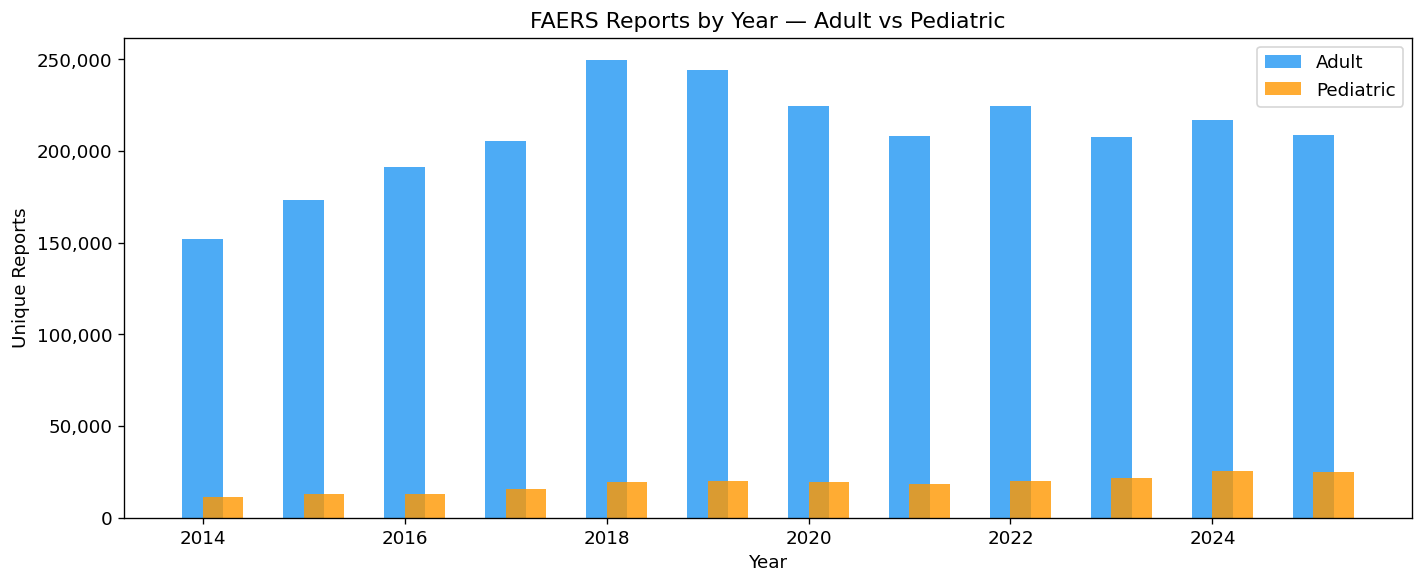

In [5]:
# Unique reports per year, side by side
def reports_by_year(df, name):
    return (
        df.filter(pl.col("receive_date").is_not_null())
        .with_columns(pl.col("receive_date").dt.year().alias("year"))
        .group_by("year").agg(pl.col("safetyreportid").n_unique().alias("reports"))
        .sort("year")
        .with_columns(pl.lit(name).alias("cohort"))
    )

yearly = pl.concat([reports_by_year(adult, "Adult"), reports_by_year(pediatric, "Pediatric")])

fig, ax = plt.subplots()
for cohort, color in [("Adult", "#2196F3"), ("Pediatric", "#FF9800")]:
    subset = yearly.filter(pl.col("cohort") == cohort).sort("year")
    ax.bar(subset["year"].to_list(), subset["reports"].to_list(), label=cohort, alpha=0.8, color=color, width=0.4 if cohort == "Adult" else 0.4, align="center" if cohort == "Adult" else "edge")
ax.set_xlabel("Year")
ax.set_ylabel("Unique Reports")
ax.set_title("FAERS Reports by Year — Adult vs Pediatric")
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig("../notebook/reports_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Age Distribution

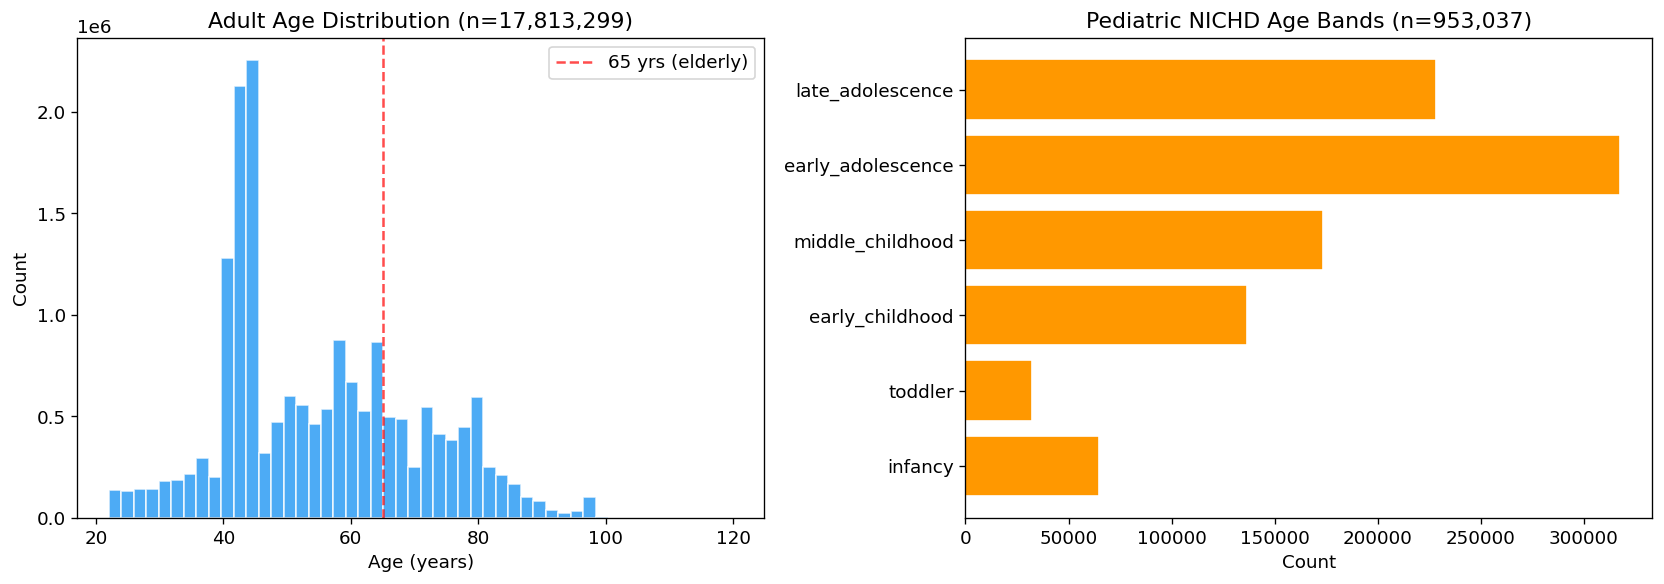

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Adult age histogram
adult_ages = adult.filter(pl.col("age_years").is_not_null())["age_years"].to_list()
axes[0].hist(adult_ages, bins=50, color="#2196F3", edgecolor="white", alpha=0.8)
axes[0].set_title(f"Adult Age Distribution (n={len(adult_ages):,})")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Count")
axes[0].axvline(x=65, color="red", linestyle="--", alpha=0.7, label="65 yrs (elderly)")
axes[0].legend()

# Pediatric: NICHD age bands (if available)
if "nichd" in pediatric.columns:
    nichd_order = ["infancy", "toddler", "early_childhood", "middle_childhood", "early_adolescence", "late_adolescence"]
    nichd_counts = (
        pediatric.filter(pl.col("nichd").is_not_null())
        .group_by("nichd").agg(pl.len().alias("count"))
    )
    # Sort by predefined clinical order using a manual join
    order_df = pl.DataFrame({"nichd": nichd_order, "_order": list(range(len(nichd_order)))})
    nichd_counts = nichd_counts.join(order_df, on="nichd", how="left").sort("_order")

    axes[1].barh(nichd_counts["nichd"].to_list(), nichd_counts["count"].to_list(), color="#FF9800", edgecolor="white")
    axes[1].set_title(f"Pediatric NICHD Age Bands (n={pediatric.height:,})")
    axes[1].set_xlabel("Count")
else:
    ped_ages = pediatric.filter(pl.col("age_years").is_not_null())["age_years"].to_list()
    axes[1].hist(ped_ages, bins=22, color="#FF9800", edgecolor="white", alpha=0.8)
    axes[1].set_title(f"Pediatric Age Distribution (n={len(ped_ages):,})")
    axes[1].set_xlabel("Age (years)")
    axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../notebook/age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Top 20 Drugs (by report frequency)

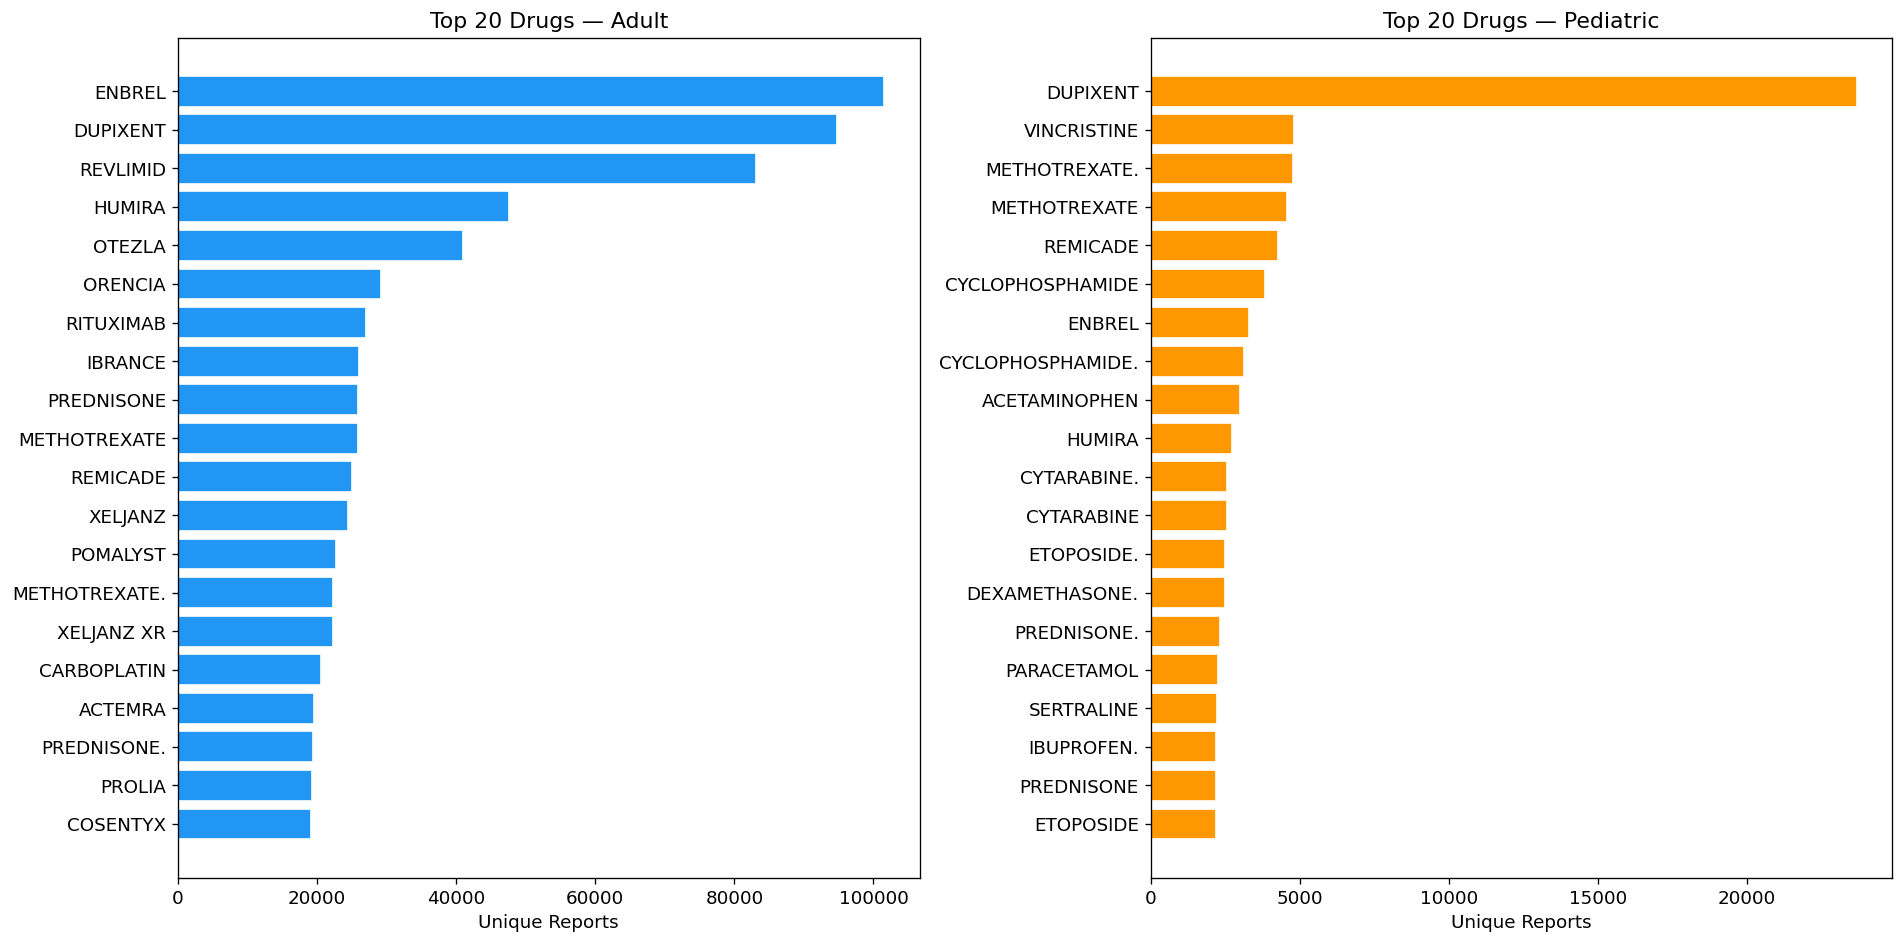

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, df, name, color in [(axes[0], adult, "Adult", "#2196F3"), (axes[1], pediatric, "Pediatric", "#FF9800")]:
    top_drugs = (
        df.group_by("medicinal_product")
        .agg(pl.col("safetyreportid").n_unique().alias("reports"))
        .sort("reports", descending=True)
        .head(20)
    )
    ax.barh(
        top_drugs["medicinal_product"].to_list()[::-1],
        top_drugs["reports"].to_list()[::-1],
        color=color, edgecolor="white"
    )
    ax.set_title(f"Top 20 Drugs — {name}")
    ax.set_xlabel("Unique Reports")

plt.tight_layout()
plt.savefig("../notebook/top20_drugs.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Top 20 Adverse Reactions (MedDRA PT)

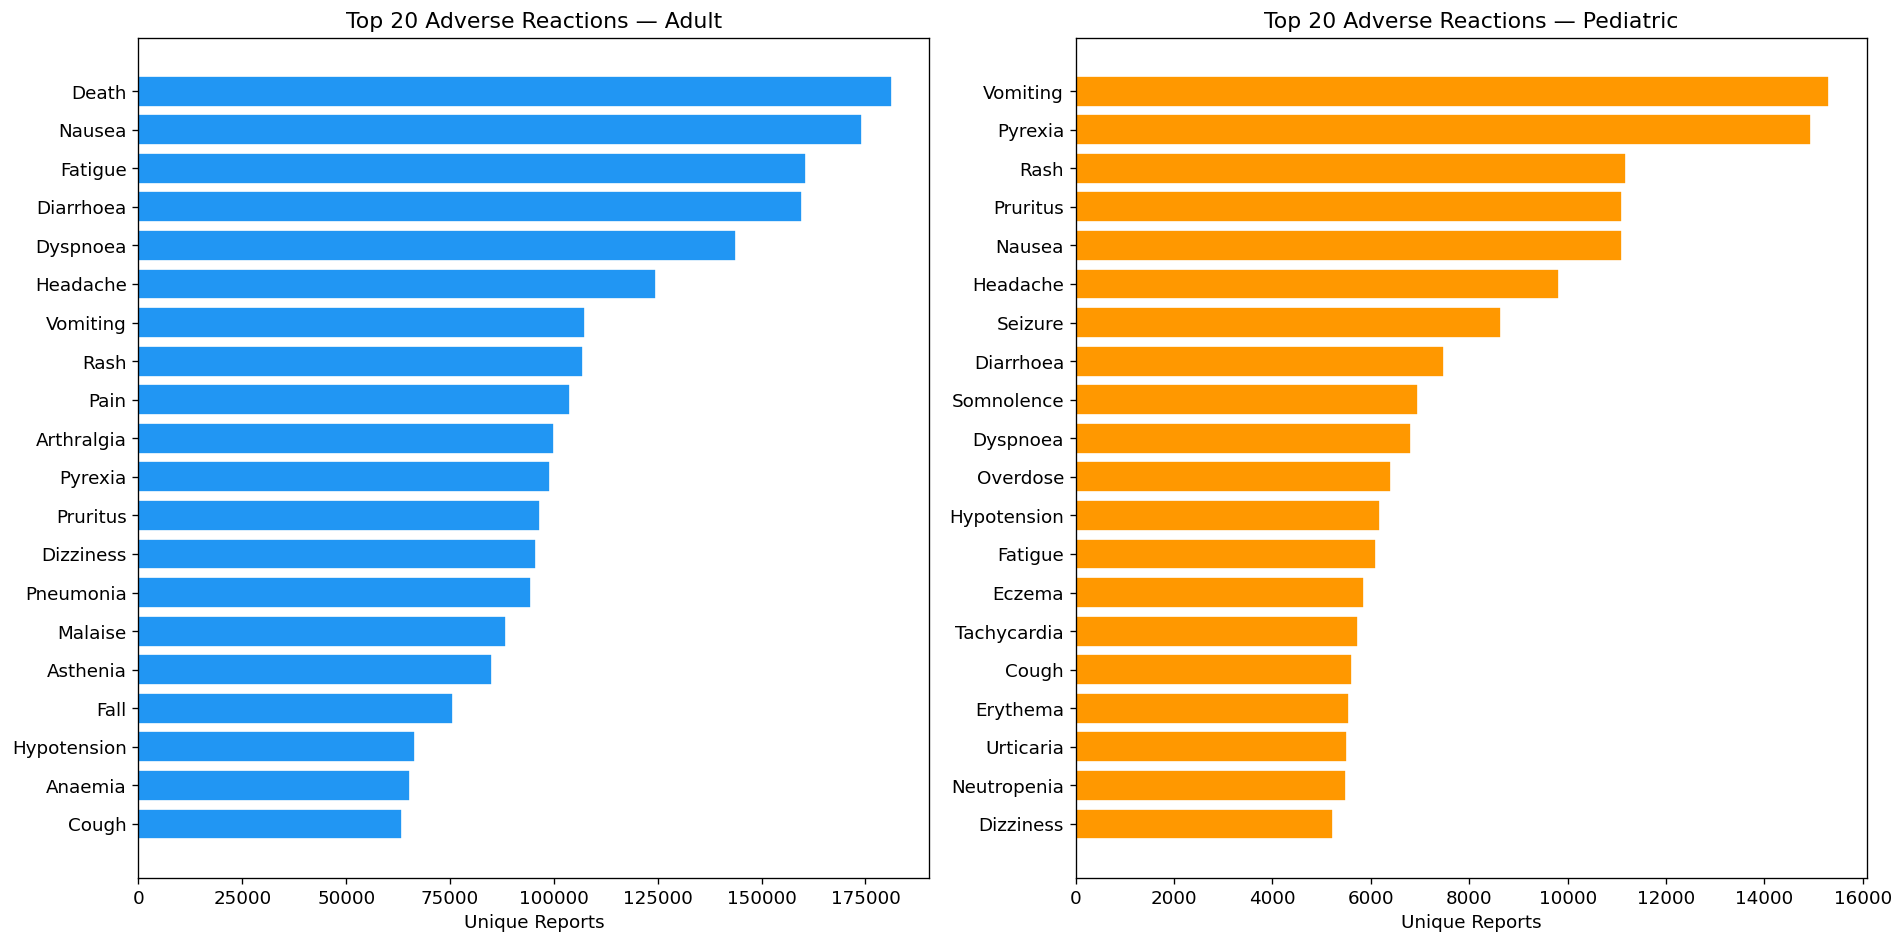

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, df, name, color in [(axes[0], adult, "Adult", "#2196F3"), (axes[1], pediatric, "Pediatric", "#FF9800")]:
    top_rxn = (
        df.group_by("reaction_meddrapt")
        .agg(pl.col("safetyreportid").n_unique().alias("reports"))
        .sort("reports", descending=True)
        .head(20)
    )
    ax.barh(
        top_rxn["reaction_meddrapt"].to_list()[::-1],
        top_rxn["reports"].to_list()[::-1],
        color=color, edgecolor="white"
    )
    ax.set_title(f"Top 20 Adverse Reactions — {name}")
    ax.set_xlabel("Unique Reports")

plt.tight_layout()
# plt.savefig("../notebook/top20_reactions.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. MedDRA SOC Distribution (System Organ Class)

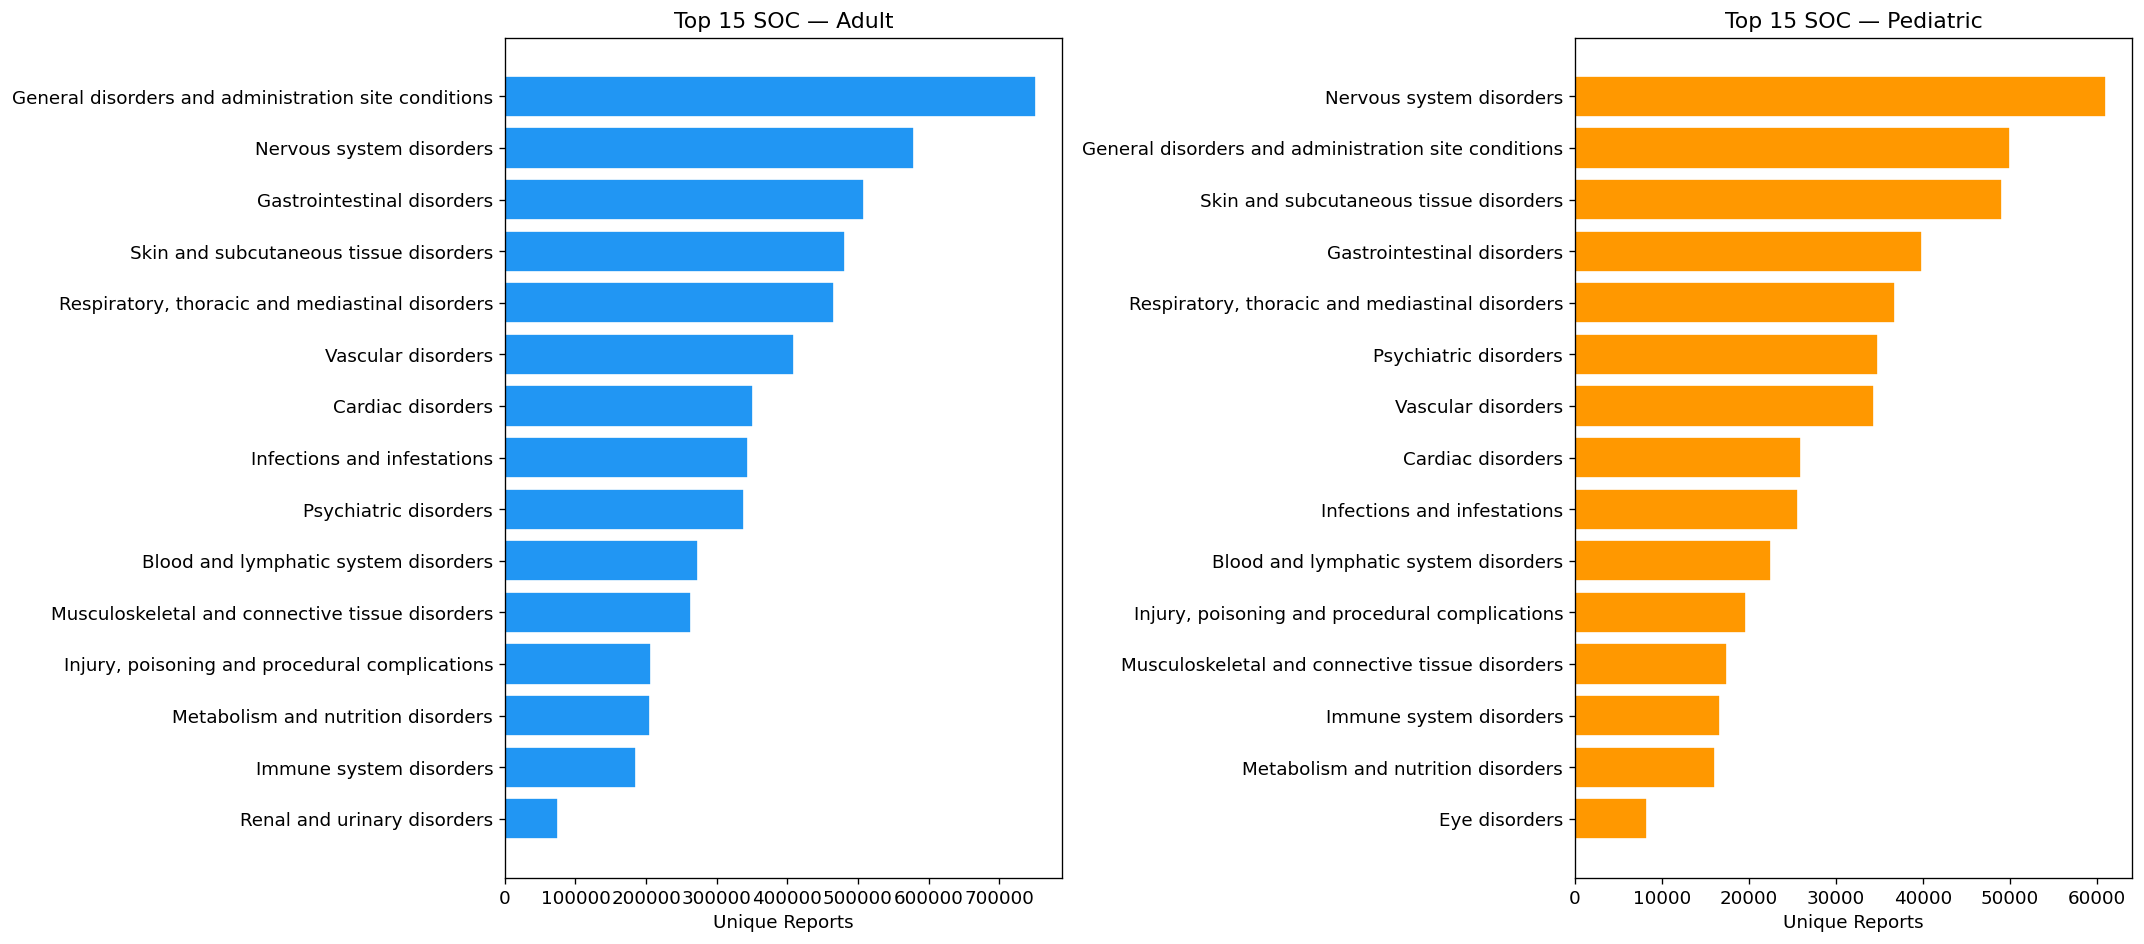

In [9]:
# Explode SOC lists and count unique reports per SOC
def soc_distribution(df, name):
    if "meddra_soc_names" not in df.columns:
        return pl.DataFrame()
    return (
        df.select("safetyreportid", "meddra_soc_names")
        .explode("meddra_soc_names")
        .filter(pl.col("meddra_soc_names").is_not_null())
        .group_by("meddra_soc_names")
        .agg(pl.col("safetyreportid").n_unique().alias("reports"))
        .sort("reports", descending=True)
        .with_columns(pl.lit(name).alias("cohort"))
    )

soc_adult = soc_distribution(adult, "Adult")
soc_ped = soc_distribution(pediatric, "Pediatric")

if soc_adult.height > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    for ax, soc_df, name, color in [(axes[0], soc_adult, "Adult", "#2196F3"), (axes[1], soc_ped, "Pediatric", "#FF9800")]:
        top_soc = soc_df.head(15)
        ax.barh(
            top_soc["meddra_soc_names"].to_list()[::-1],
            top_soc["reports"].to_list()[::-1],
            color=color, edgecolor="white"
        )
        ax.set_title(f"Top 15 SOC — {name}")
        ax.set_xlabel("Unique Reports")
    plt.tight_layout()
    # plt.savefig("../notebook/soc_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("meddra_soc_names column not available")

## 8. Seriousness Outcome Breakdown

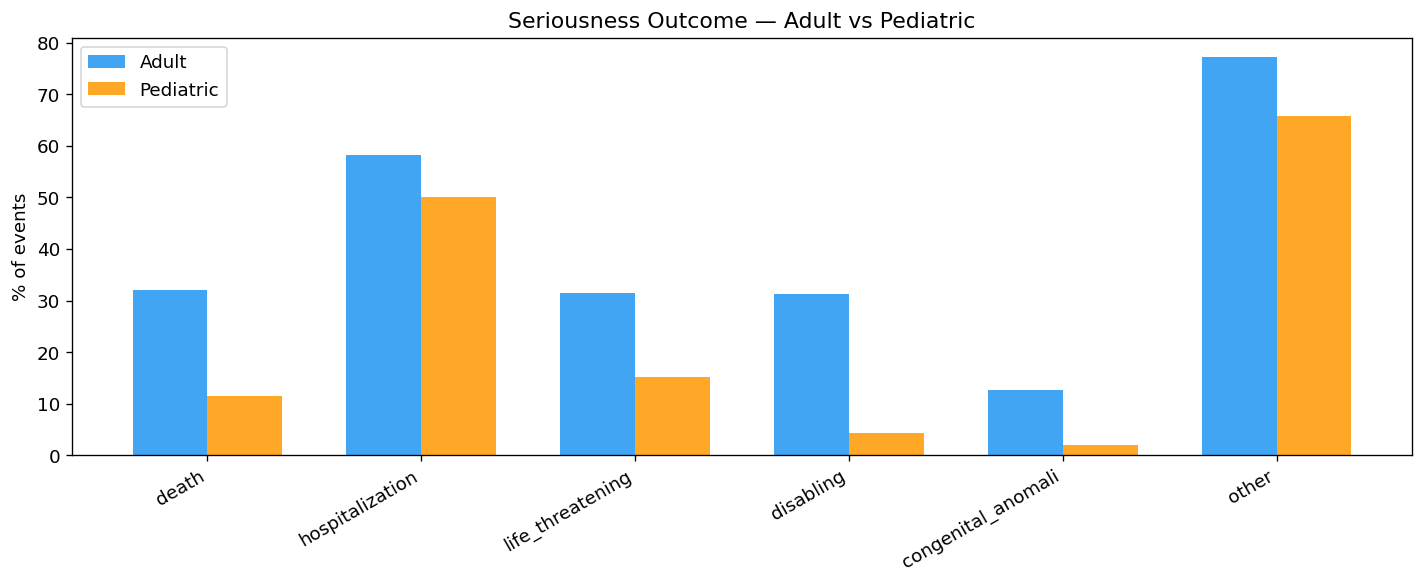

outcome,count,pct,cohort
str,i64,f64,str
"""death""",5717387,32.1,"""Adult"""
"""hospitalization""",10381437,58.28,"""Adult"""
"""life_threatening""",5613108,31.51,"""Adult"""
"""disabling""",5561391,31.22,"""Adult"""
"""congenital_anomali""",2249993,12.63,"""Adult"""
…,…,…,…
"""hospitalization""",476802,50.03,"""Pediatric"""
"""life_threatening""",145501,15.27,"""Pediatric"""
"""disabling""",41162,4.32,"""Pediatric"""


In [10]:
# Seriousness flags: death, hospitalization, life_threatening, disabling, congenital_anomali, other
serious_flags = ["death", "hospitalization", "life_threatening", "disabling", "congenital_anomali", "other"]

def serious_breakdown(df, name):
    available = [f for f in serious_flags if f in df.columns]
    rows = []
    total = df.height
    for flag in available:
        count = df.filter(pl.col(flag) == 1).height
        rows.append({"outcome": flag, "count": count, "pct": round(count / total * 100, 2) if total > 0 else 0})
    return pl.DataFrame(rows).with_columns(pl.lit(name).alias("cohort"))

sb = pl.concat([serious_breakdown(adult, "Adult"), serious_breakdown(pediatric, "Pediatric")])

fig, ax = plt.subplots(figsize=(12, 5))
x_labels = sb.filter(pl.col("cohort") == "Adult")["outcome"].to_list()
adult_pcts = sb.filter(pl.col("cohort") == "Adult")["pct"].to_list()
ped_pcts = sb.filter(pl.col("cohort") == "Pediatric")["pct"].to_list()

import numpy as np
x = np.arange(len(x_labels))
w = 0.35
ax.bar(x - w/2, adult_pcts, w, label="Adult", color="#2196F3", alpha=0.85)
ax.bar(x + w/2, ped_pcts, w, label="Pediatric", color="#FF9800", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_ylabel("% of events")
ax.set_title("Seriousness Outcome — Adult vs Pediatric")
ax.legend()
plt.tight_layout()
# plt.savefig("../notebook/seriousness_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

display(sb)

## 9. Sex Distribution

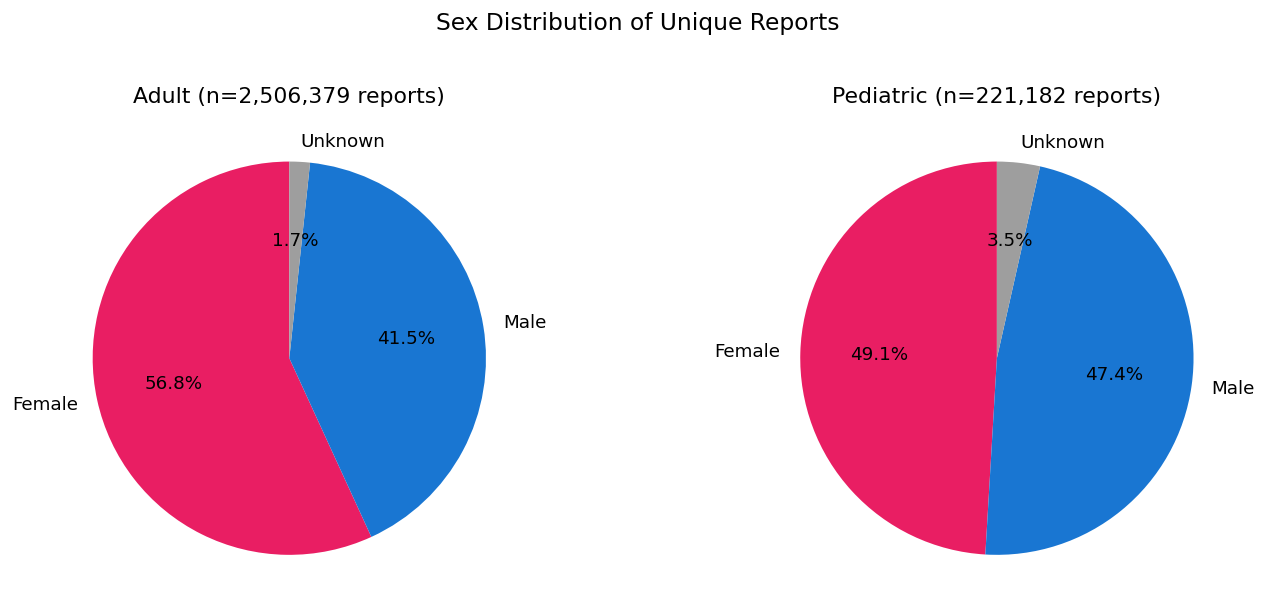

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, name in [(axes[0], adult, "Adult"), (axes[1], pediatric, "Pediatric")]:
    sex_counts = (
        df.group_by("patient_sex")
        .agg(pl.col("safetyreportid").n_unique().alias("reports"))
        .sort("reports", descending=True)
    )
    colors = {"Female": "#E91E63", "Male": "#1976D2", "Unknown": "#9E9E9E"}
    c = [colors.get(s, "#757575") for s in sex_counts["patient_sex"].to_list()]
    ax.pie(
        sex_counts["reports"].to_list(),
        labels=sex_counts["patient_sex"].to_list(),
        autopct="%1.1f%%",
        colors=c,
        startangle=90,
    )
    ax.set_title(f"{name} (n={df['safetyreportid'].n_unique():,} reports)")

plt.suptitle("Sex Distribution of Unique Reports", fontsize=14, y=1.02)
plt.tight_layout()
# plt.savefig("../notebook/sex_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Reporter Country — Top 15

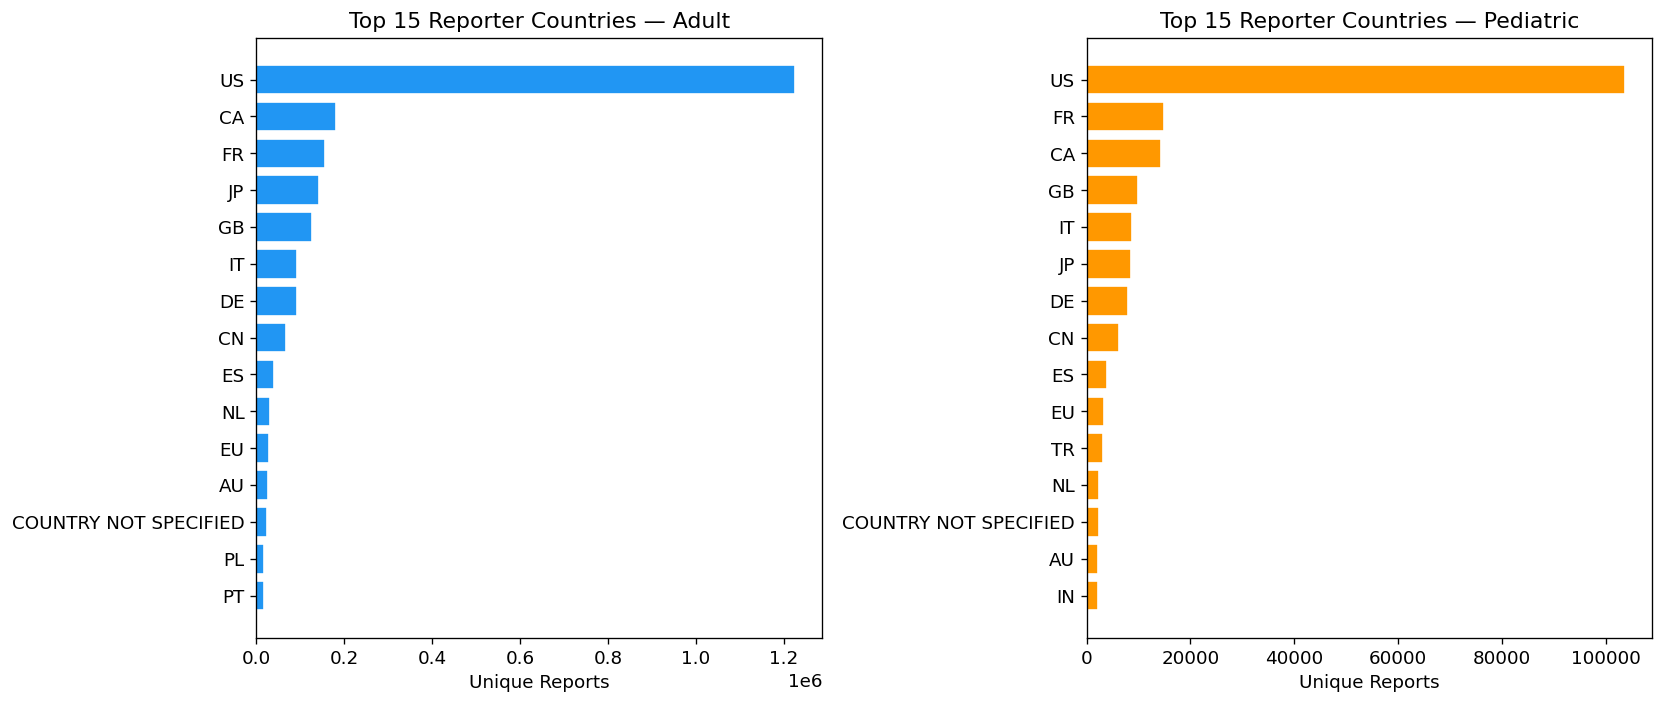

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, name, color in [(axes[0], adult, "Adult", "#2196F3"), (axes[1], pediatric, "Pediatric", "#FF9800")]:
    country = (
        df.filter(pl.col("reporter_country").is_not_null() & (pl.col("reporter_country") != "Unknown"))
        .group_by("reporter_country")
        .agg(pl.col("safetyreportid").n_unique().alias("reports"))
        .sort("reports", descending=True)
        .head(15)
    )
    ax.barh(
        country["reporter_country"].to_list()[::-1],
        country["reports"].to_list()[::-1],
        color=color, edgecolor="white"
    )
    ax.set_title(f"Top 15 Reporter Countries — {name}")
    ax.set_xlabel("Unique Reports")

plt.tight_layout()
# plt.savefig("../notebook/reporter_country.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Combination vs Single-Ingredient Products

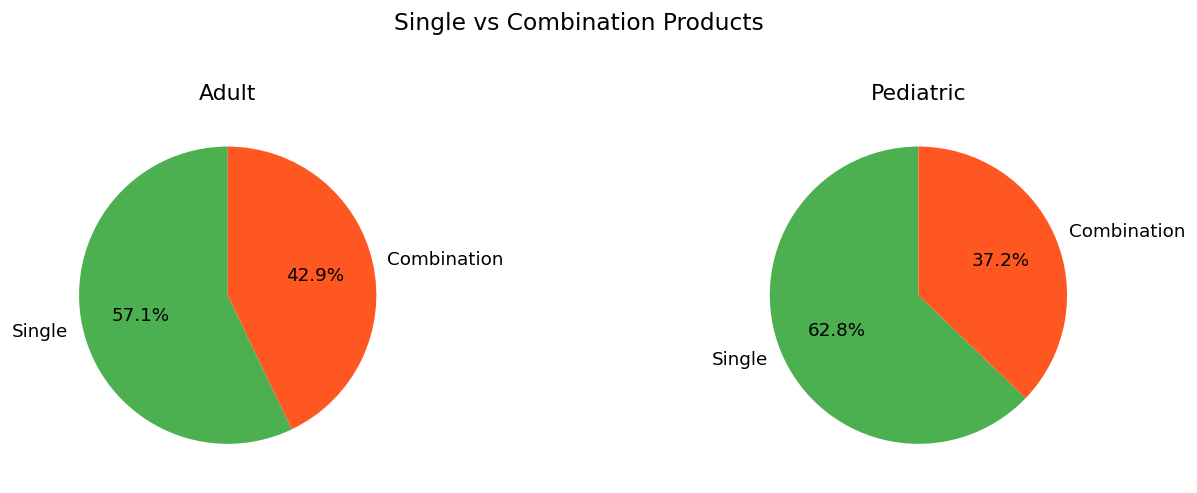

In [13]:
if "is_combination_product" in adult.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, df, name in [(axes[0], adult, "Adult"), (axes[1], pediatric, "Pediatric")]:
        combo = df.group_by("is_combination_product").agg(pl.len().alias("count"))
        labels = ["Single" if not v else "Combination" for v in combo["is_combination_product"].to_list()]
        ax.pie(combo["count"].to_list(), labels=labels, autopct="%1.1f%%", colors=["#4CAF50", "#FF5722"], startangle=90)
        ax.set_title(f"{name}")
    plt.suptitle("Single vs Combination Products", fontsize=14, y=1.02)
    plt.tight_layout()
    # plt.savefig("../notebook/combination_products.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("is_combination_product column not available")

## 12. Data Quality Summary

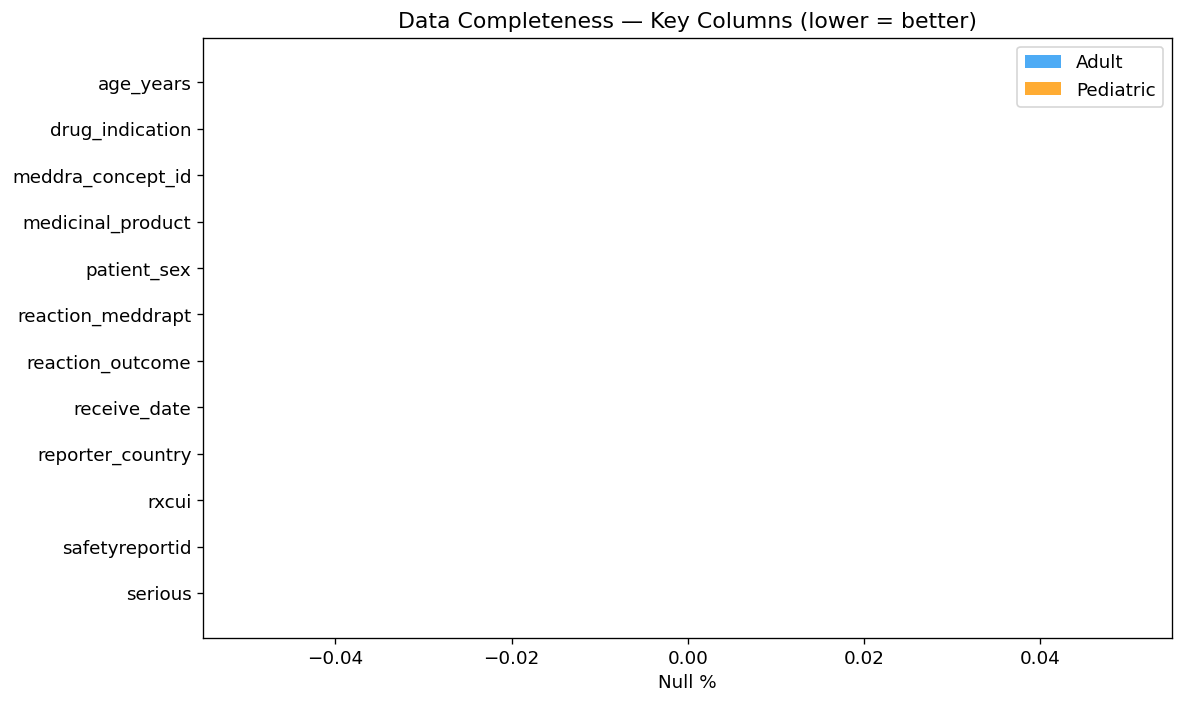

### Full null % table

column,Adult,Pediatric
str,f64,f64
"""age_years""",0.0,0.0
"""congenital_anomali""",0.0,0.0
"""death""",0.0,0.0
"""disabling""",0.0,0.0
"""drug_administration""",0.0,0.0
…,…,…
"""reporter_country""",0.0,0.0
"""reporter_qualification""",0.0,0.0
"""rxcui""",0.0,0.0


In [14]:
# Data completeness heatmap (null % per column per cohort)
def null_pct_table(df, name):
    rows = []
    for col in df.columns:
        null_pct = round(df[col].null_count() / df.height * 100, 1) if df.height > 0 else 0
        rows.append({"column": col, "null_pct": null_pct})
    return pl.DataFrame(rows).with_columns(pl.lit(name).alias("cohort"))

null_df = pl.concat([null_pct_table(adult, "Adult"), null_pct_table(pediatric, "Pediatric")])
pivot_null = null_df.pivot(on="cohort", index="column", values="null_pct").sort("column")

# Horizontal bar chart showing null % for key columns
key_cols = [
    "safetyreportid", "age_years", "patient_sex", "receive_date",
    "medicinal_product", "rxcui", "reaction_meddrapt", "reaction_outcome",
    "meddra_concept_id", "serious", "reporter_country", "drug_indication",
]
key_null = pivot_null.filter(pl.col("column").is_in(key_cols))

fig, ax = plt.subplots(figsize=(10, 6))
y = range(len(key_null))
ax.barh([i + 0.2 for i in y], key_null["Adult"].to_list(), 0.35, label="Adult", color="#2196F3", alpha=0.8)
ax.barh([i - 0.2 for i in y], key_null["Pediatric"].to_list(), 0.35, label="Pediatric", color="#FF9800", alpha=0.8)
ax.set_yticks(list(y))
ax.set_yticklabels(key_null["column"].to_list())
ax.set_xlabel("Null %")
ax.set_title("Data Completeness — Key Columns (lower = better)")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
# plt.savefig("../notebook/data_quality.png", dpi=150, bbox_inches="tight")
plt.show()

display(Markdown("### Full null % table"))
display(pivot_null)

---

## Summary

| Metric | Adult | Pediatric |
|--------|-------|-----------|
| Total event rows | `adult.height` | `pediatric.height` |
| Unique reports | `safetyreportid.n_unique()` | ... |
| Unique drugs | `medicinal_product.n_unique()` | ... |
| Unique reactions | `reaction_meddrapt.n_unique()` | ... |
| Date range | 2014–2025 | 2014–2025 |

Charts saved to `notebook/*.png` for use in publications.